# MICU Supply Usage Analysis - January 2026

This notebook analyzes the top 12 highest-usage supply items in the MICU based on average daily usage during January 2026.

## Data Source
- **File**: `12_Highest_Usage.csv`
- **Period**: January 1-22, 2026
- **Location**: UHMIC - UH MICU

## Setup

Import necessary libraries for data analysis and visualization.

In [2]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

## Load Data

Load the top 12 highest-usage items from the processed data file.

In [3]:
# Load the data
df = pd.read_csv('../data/processed/12_Highest_Usage.csv', keep_default_na=False, na_values=[''])

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)

Dataset shape: (12, 12)

Column names: ['item_no', 'avg_daily_usage', 'std_dev', 'max_z_score', 'calc_min', 'old_min', 'req_min', 'calc_max', 'old_max', 'req_max', 'item_desc', 'bin_loc']

Data types:
item_no                str
avg_daily_usage    float64
std_dev            float64
max_z_score        float64
calc_min             int64
old_min              int64
req_min              int64
calc_max             int64
old_max              int64
req_max              int64
item_desc              str
bin_loc                str
dtype: object


## Initial Data Exploration

Display the top 12 items and examine basic statistics.

In [4]:
# Display all 12 items
df

,item_no,avg_daily_usage,std_dev,max_z_score,calc_min,old_min,req_min,calc_max,old_max,req_max,item_desc,bin_loc
0,85968,53.05,52.61,3.00,213,10,600,425,89,1000,FLUSH SALINE NORMAL10ML NOVAPLUS,07D07
1,83188,24.55,10.67,1.64,99,50,100,197,100,300,WIPE CLEANING THERAWORX,02F10
2,17960,22.91,29.96,2.74,92,50,500,184,100,1000,NEEDLE HYPO 1.5IN 18GA BLUNT FILL,07B06
3,89020S,19.23,70.53,4.42,77,100,1000,154,200,3000,CAP DISINFECTION PUREHUB DISPOSABLE,07A05
4,210753,17.77,44.05,4.16,72,300,1000,143,600,3000,SWAB PREVANTICS ANTISEPTIC DEVICE 3.125IN 1.125IN,07A07
5,5168S,12.50,14.11,2.23,50,100,250,100,200,500,SYRINGE LUER-LOCK 3ML SINGLE USE LF (USE 5168),07A01
6,73721,11.55,5.11,2.05,47,30,250,93,40,500,SET INFUSION CHECK VALVE 126IN,07E03
7,39270,11.41,3.65,2.08,46,5,25,92,15,50,UNDERPAD INCONTINENCE DRYPAD COMFORT GLIDE 36I...,01B01
8,34234,11.23,16.38,2.61,45,50,250,90,100,500,SYRINGE LUER LOK 10ML STER,07A03
9,89238,8.32,3.97,1.94,34,15,25,67,30,50,DRESSING MEPILEX SACREM BORDER 22CM 25CM,02F08


---
## Analysis Sections

## Inventory Level Comparisons

Compare calculated, old, and requested minimum and maximum inventory levels for each item.

In [5]:
# Prepare data for plotting
import matplotlib.patches as mpatches

# Get item numbers for labeling (shortened for readability)
items = df['item_no'].astype(str).tolist()

# Extract min and max values
calc_min = df['calc_min'].values
old_min = df['old_min'].values
req_min = df['req_min'].values

calc_max = df['calc_max'].values
old_max = df['old_max'].values
req_max = df['req_max'].values

# Set up bar positions
n_items = len(df)
bar_width = 0.25
x = np.arange(n_items)

# Generate 12 distinct colors (one per item)
base_colors = plt.cm.tab10(np.linspace(0, 1, 10)).tolist() + plt.cm.Set3(np.linspace(0, 1, 2)).tolist()
base_colors = base_colors[:n_items]

### Minimum Inventory Levels

Comparison of calculated, old, and requested minimum inventory levels.

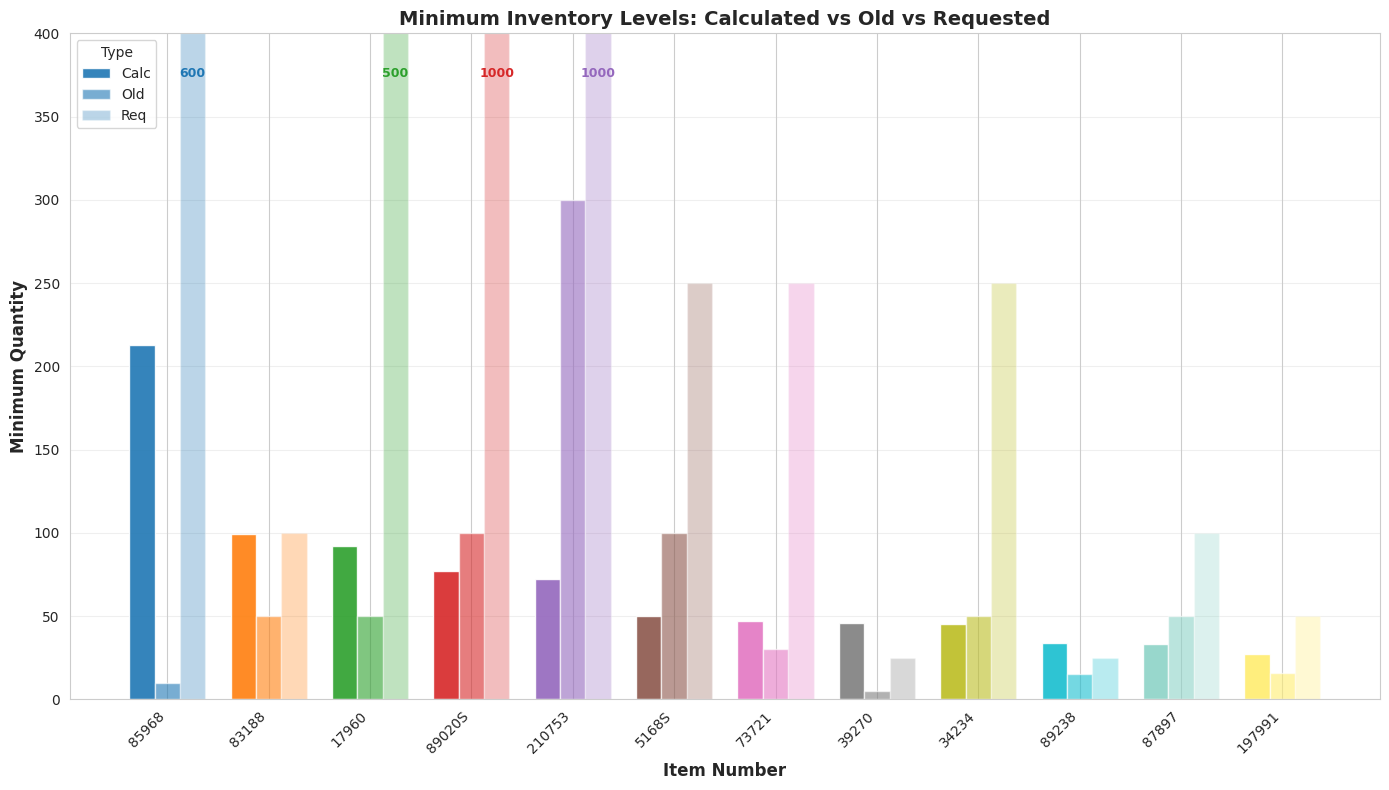

In [6]:
# Create figure for minimums
fig, ax = plt.subplots(figsize=(14, 8))

# Y-axis limit for minimums
y_limit_min = 400

# Plot bars for each item with different saturations
for i in range(n_items):
    color = base_colors[i]
    
    # Cap values at y_limit for display, but track actual values
    calc_display = min(calc_min[i], y_limit_min)
    old_display = min(old_min[i], y_limit_min)
    req_display = min(req_min[i], y_limit_min)
    
    # Create three variations of the same color (different alphas/saturations)
    ax.bar(x[i] - bar_width, calc_display, bar_width, 
           color=color, alpha=0.9, label='Calc' if i == 0 else '')
    ax.bar(x[i], old_display, bar_width, 
           color=color, alpha=0.6, label='Old' if i == 0 else '')
    ax.bar(x[i] + bar_width, req_display, bar_width, 
           color=color, alpha=0.3, label='Req' if i == 0 else '')
    
    # Add labels for values exceeding y_limit
    if calc_min[i] > y_limit_min:
        ax.text(x[i] - bar_width, y_limit_min - 20, f'{calc_min[i]:.0f}', 
                ha='center', va='top', fontsize=9, fontweight='bold', color=color)
    
    if old_min[i] > y_limit_min:
        ax.text(x[i], y_limit_min - 20, f'{old_min[i]:.0f}', 
                ha='center', va='top', fontsize=9, fontweight='bold', color=color)
    
    if req_min[i] > y_limit_min:
        ax.text(x[i] + bar_width, y_limit_min - 20, f'{req_min[i]:.0f}', 
                ha='center', va='top', fontsize=9, fontweight='bold', color=color)

# Customize plot
ax.set_xlabel('Item Number', fontsize=12, fontweight='bold')
ax.set_ylabel('Minimum Quantity', fontsize=12, fontweight='bold')
ax.set_title('Minimum Inventory Levels: Calculated vs Old vs Requested', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(items, rotation=45, ha='right')
ax.set_ylim(0, y_limit_min)
ax.legend(title='Type', loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Maximum Inventory Levels

Comparison of calculated, old, and requested maximum inventory levels.

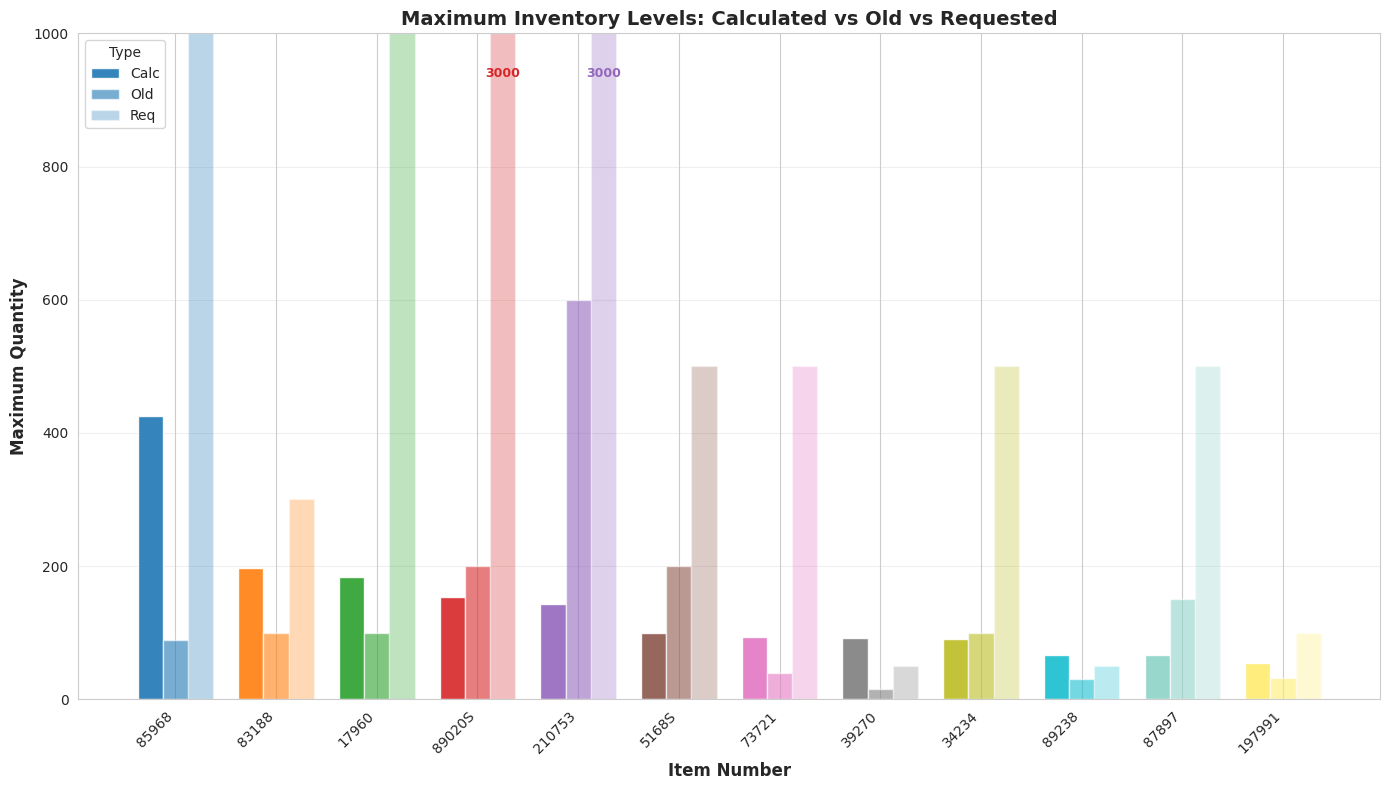

In [7]:
# Create figure for maximums
fig, ax = plt.subplots(figsize=(14, 8))

# Y-axis limit for maximums
y_limit_max = 1000

# Plot bars for each item with different saturations
for i in range(n_items):
    color = base_colors[i]
    
    # Cap values at y_limit for display, but track actual values
    calc_display = min(calc_max[i], y_limit_max)
    old_display = min(old_max[i], y_limit_max)
    req_display = min(req_max[i], y_limit_max)
    
    # Create three variations of the same color (different alphas/saturations)
    ax.bar(x[i] - bar_width, calc_display, bar_width, 
           color=color, alpha=0.9, label='Calc' if i == 0 else '')
    ax.bar(x[i], old_display, bar_width, 
           color=color, alpha=0.6, label='Old' if i == 0 else '')
    ax.bar(x[i] + bar_width, req_display, bar_width, 
           color=color, alpha=0.3, label='Req' if i == 0 else '')
    
    # Add labels for values exceeding y_limit
    if calc_max[i] > y_limit_max:
        ax.text(x[i] - bar_width, y_limit_max - 50, f'{calc_max[i]:.0f}', 
                ha='center', va='top', fontsize=9, fontweight='bold', color=color)
    
    if old_max[i] > y_limit_max:
        ax.text(x[i], y_limit_max - 50, f'{old_max[i]:.0f}', 
                ha='center', va='top', fontsize=9, fontweight='bold', color=color)
    
    if req_max[i] > y_limit_max:
        ax.text(x[i] + bar_width, y_limit_max - 50, f'{req_max[i]:.0f}', 
                ha='center', va='top', fontsize=9, fontweight='bold', color=color)

# Customize plot
ax.set_xlabel('Item Number', fontsize=12, fontweight='bold')
ax.set_ylabel('Maximum Quantity', fontsize=12, fontweight='bold')
ax.set_title('Maximum Inventory Levels: Calculated vs Old vs Requested', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(items, rotation=45, ha='right')
ax.set_ylim(0, y_limit_max)
ax.legend(title='Type', loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Maximum Z-Score Analysis

Z-score represents how many standard deviations the highest usage day was from the average daily usage. Higher z-scores indicate more extreme usage spikes.

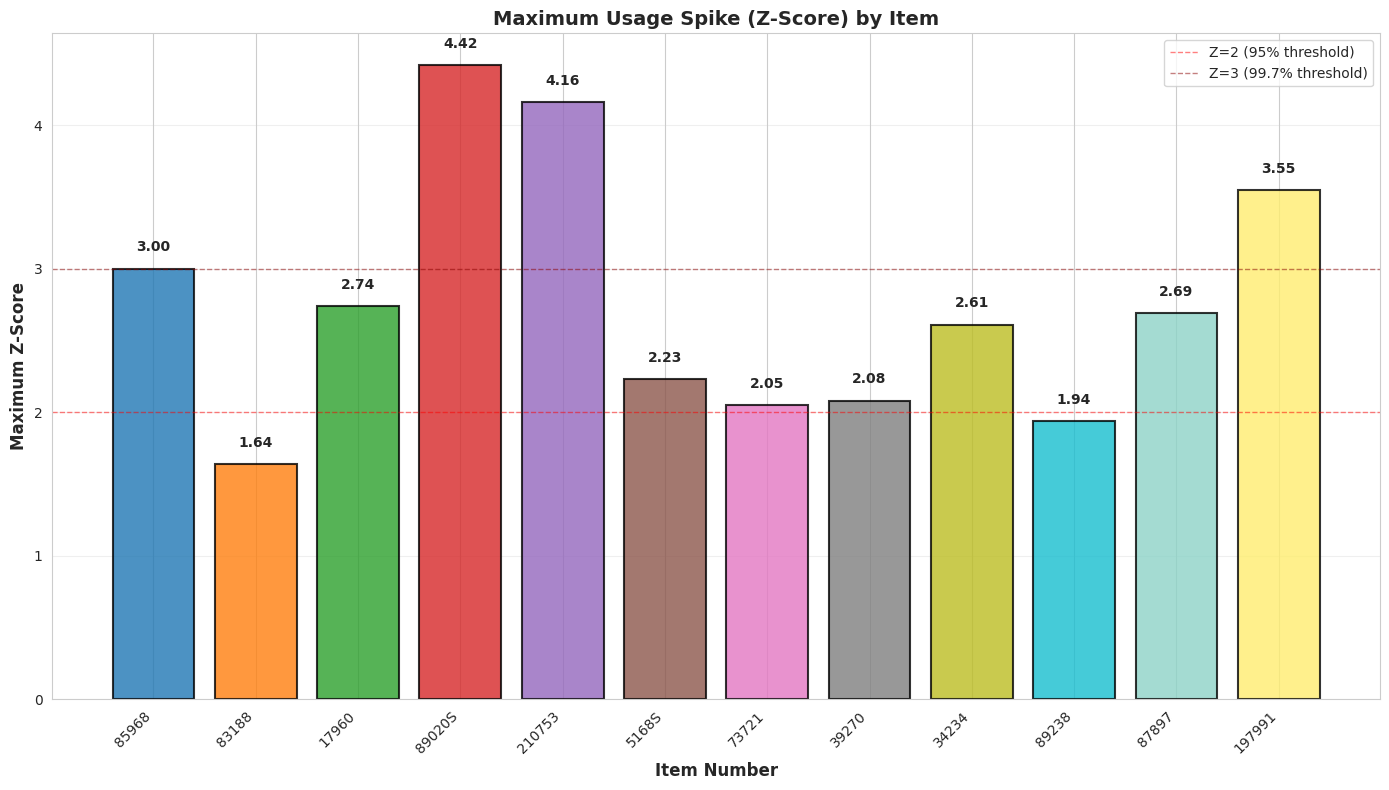

In [8]:
# Create figure for max z-scores
fig, ax = plt.subplots(figsize=(14, 8))

# Get max z-scores
max_z_scores = df['max_z_score'].values

# Plot bars with individual colors per item
bars = ax.bar(x, max_z_scores, color=base_colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on top of each bar
for i, (bar, z_score) in enumerate(zip(bars, max_z_scores)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{z_score:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Customize plot
ax.set_xlabel('Item Number', fontsize=12, fontweight='bold')
ax.set_ylabel('Maximum Z-Score', fontsize=12, fontweight='bold')
ax.set_title('Maximum Usage Spike (Z-Score) by Item', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(items, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=2, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Z=2 (95% threshold)')
ax.axhline(y=3, color='darkred', linestyle='--', linewidth=1, alpha=0.5, label='Z=3 (99.7% threshold)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [9]:
# Calculate ratios (calc / old)
# Handle division by zero by replacing with NaN
calc_old_min_ratio = np.where(old_min != 0, calc_min / old_min, np.nan)
calc_old_max_ratio = np.where(old_max != 0, calc_max / old_max, np.nan)

#### Minimum Level Ratios (Calc/Old)

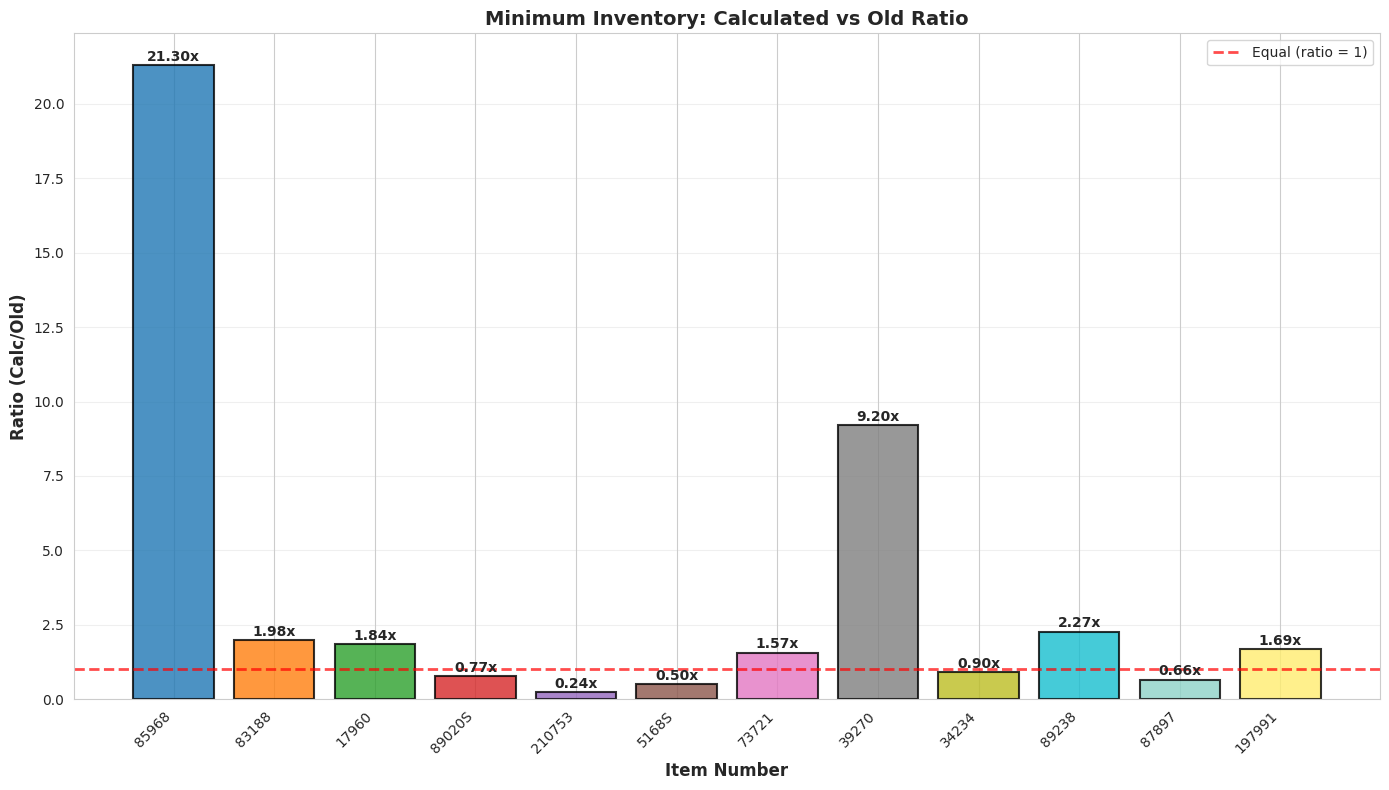

In [10]:
# Create figure for min ratios
fig, ax = plt.subplots(figsize=(14, 8))

# Plot bars with individual colors per item
bars = ax.bar(x, calc_old_min_ratio, color=base_colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on top of each bar
for i, (bar, ratio) in enumerate(zip(bars, calc_old_min_ratio)):
    if not np.isnan(ratio):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{ratio:.2f}x',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Customize plot
ax.set_xlabel('Item Number', fontsize=12, fontweight='bold')
ax.set_ylabel('Ratio (Calc/Old)', fontsize=12, fontweight='bold')
ax.set_title('Minimum Inventory: Calculated vs Old Ratio', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(items, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Equal (ratio = 1)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### Maximum Level Ratios (Calc/Old)

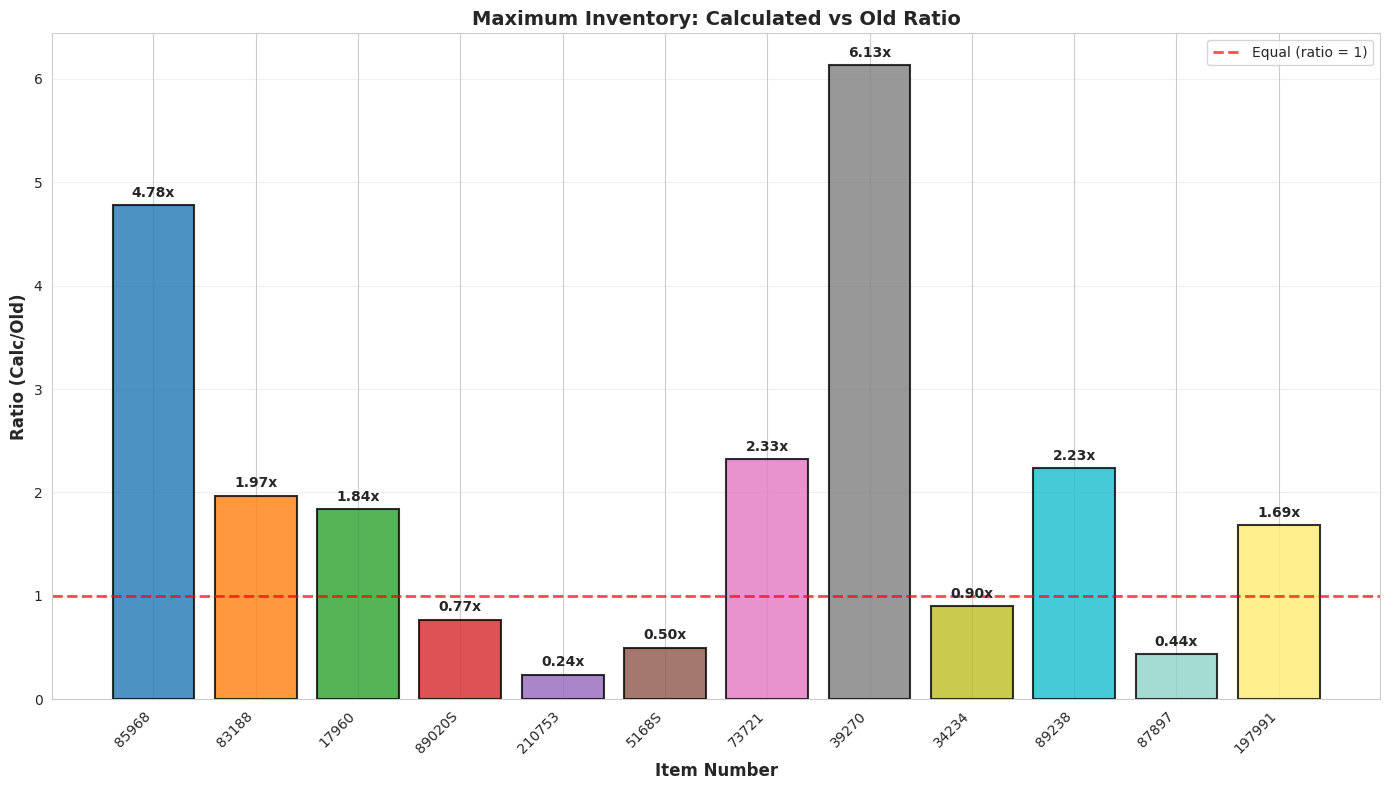

In [11]:
# Create figure for max ratios
fig, ax = plt.subplots(figsize=(14, 8))

# Plot bars with individual colors per item
bars = ax.bar(x, calc_old_max_ratio, color=base_colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on top of each bar
for i, (bar, ratio) in enumerate(zip(bars, calc_old_max_ratio)):
    if not np.isnan(ratio):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{ratio:.2f}x',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Customize plot
ax.set_xlabel('Item Number', fontsize=12, fontweight='bold')
ax.set_ylabel('Ratio (Calc/Old)', fontsize=12, fontweight='bold')
ax.set_title('Maximum Inventory: Calculated vs Old Ratio', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(items, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Equal (ratio = 1)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Daily Usage Trends

Analyze how usage varies day-to-day for the top 12 items, split into high-usage and moderate-usage groups.

In [12]:
# Load the full dataset with daily usage information
df_daily = pd.read_csv('../data/processed/MICU_Data_W_NurseReq.csv', keep_default_na=False, na_values=[''])

# Filter to only include the top 12 items and exclude placeholder dates
top_12_items = df['item_no'].astype(str).tolist()
df_daily_top12 = df_daily[df_daily['item_no'].astype(str).isin(top_12_items) & (df_daily['date'] != '00/00')]

# Convert usage to numeric
df_daily_top12['usage'] = pd.to_numeric(df_daily_top12['usage'])

print(f"Daily data shape: {df_daily_top12.shape}")
print(f"Date range: {df_daily_top12['date'].min()} to {df_daily_top12['date'].max()}")
print(f"Unique items: {df_daily_top12['item_no'].nunique()}")

Daily data shape: (264, 10)
Date range: 01/01 to 01/22
Unique items: 12


In [13]:
# Split top 12 into top 6 and bottom 6 based on avg_daily_usage
top_6_items = df.nlargest(6, 'avg_daily_usage')['item_no'].astype(str).tolist()
bottom_6_items = df.nsmallest(6, 'avg_daily_usage')['item_no'].astype(str).tolist()

print("Top 6 highest usage items:")
print(df[df['item_no'].astype(str).isin(top_6_items)][['item_no', 'item_desc', 'avg_daily_usage']])

print("\n\nBottom 6 (of top 12) usage items:")
print(df[df['item_no'].astype(str).isin(bottom_6_items)][['item_no', 'item_desc', 'avg_daily_usage']])

Top 6 highest usage items:
  item_no                                          item_desc  avg_daily_usage
0   85968                   FLUSH SALINE NORMAL10ML NOVAPLUS            53.05
1   83188                            WIPE CLEANING THERAWORX            24.55
2   17960                  NEEDLE HYPO 1.5IN 18GA BLUNT FILL            22.91
3  89020S                CAP DISINFECTION PUREHUB DISPOSABLE            19.23
4  210753  SWAB PREVANTICS ANTISEPTIC DEVICE 3.125IN 1.125IN            17.77
5   5168S     SYRINGE LUER-LOCK 3ML SINGLE USE LF (USE 5168)            12.50


Bottom 6 (of top 12) usage items:
   item_no                                          item_desc  avg_daily_usage
6    73721                     SET INFUSION CHECK VALVE 126IN            11.55
7    39270  UNDERPAD INCONTINENCE DRYPAD COMFORT GLIDE 36I...            11.41
8    34234                         SYRINGE LUER LOK 10ML STER            11.23
9    89238           DRESSING MEPILEX SACREM BORDER 22CM 25CM             8

### Top 6 Highest Usage Items - Daily Trends

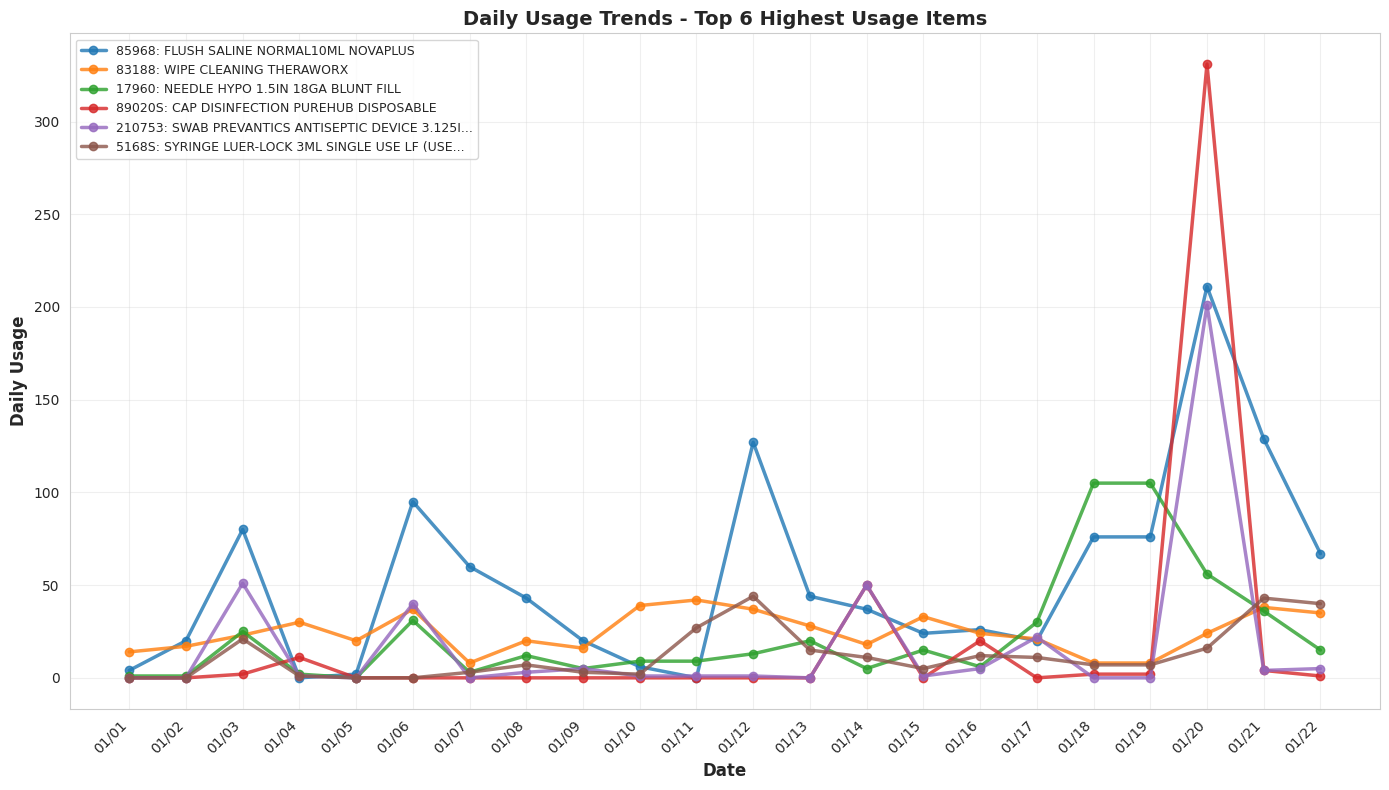

In [16]:
# Create line chart for top 6 items
fig, ax = plt.subplots(figsize=(14, 8))

# Filter data for top 6
df_top6 = df_daily_top12[df_daily_top12['item_no'].astype(str).isin(top_6_items)]

# Plot a line for each item
for i, item in enumerate(top_6_items):
    item_data = df_top6[df_top6['item_no'].astype(str) == item].sort_values('date')
    
    # Get the color for this item (match from bar charts)
    item_idx = items.index(item)
    color = base_colors[item_idx]
    
    # Get item description (limited to 40 characters)
    item_desc = df[df['item_no'].astype(str) == item]['item_desc'].values[0]
    item_desc_short = item_desc[:40] + '...' if len(item_desc) > 40 else item_desc
    
    ax.plot(item_data['date'], item_data['usage'], 
            marker='o', linewidth=2.5, markersize=6, 
            color=color, alpha=0.8, label=f'{item}: {item_desc_short}')

# Customize plot
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Daily Usage', fontsize=12, fontweight='bold')
ax.set_title('Daily Usage Trends - Top 6 Highest Usage Items', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Bottom 6 (of Top 12) Items - Daily Trends

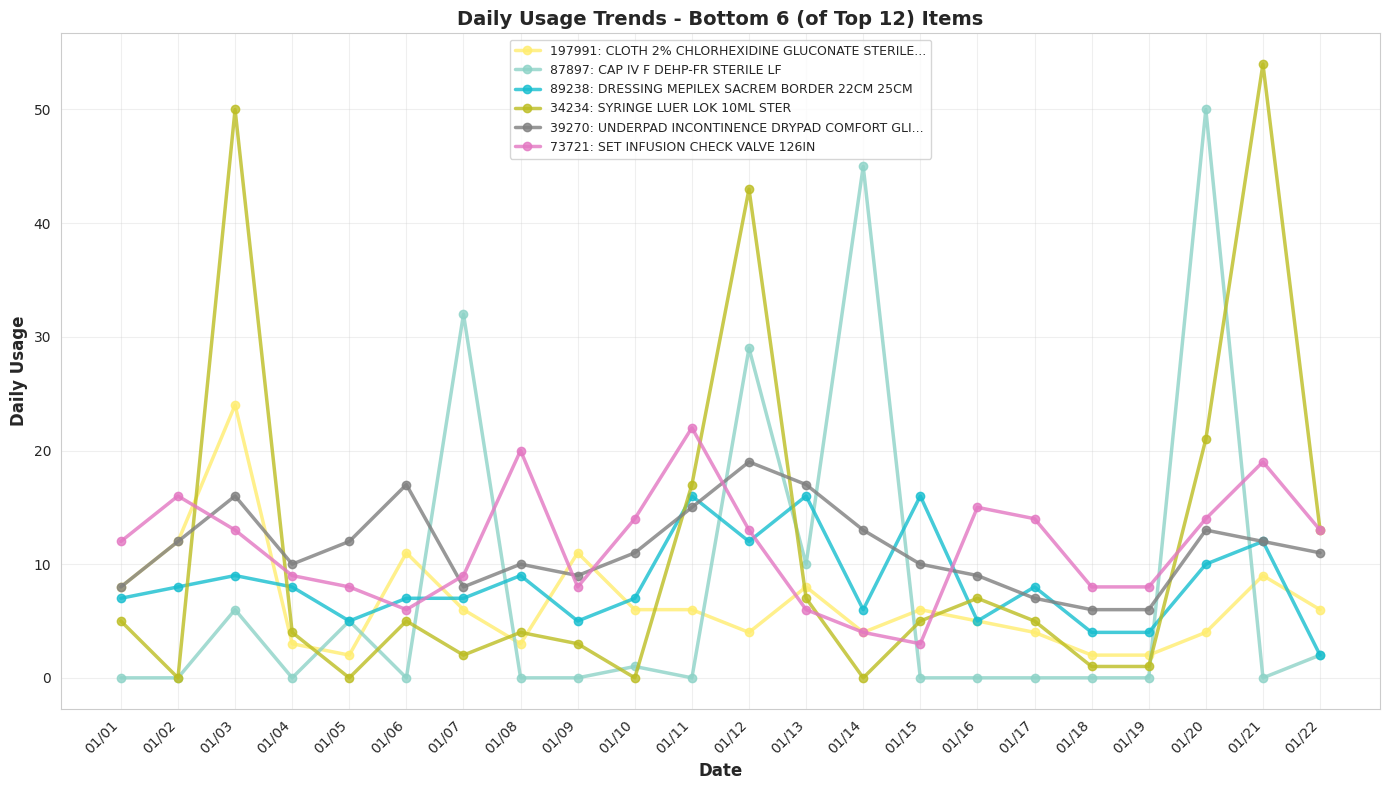

In [17]:
# Create line chart for bottom 6
fig, ax = plt.subplots(figsize=(14, 8))

# Filter data for bottom 6
df_bottom6 = df_daily_top12[df_daily_top12['item_no'].astype(str).isin(bottom_6_items)]

# Plot a line for each item
for i, item in enumerate(bottom_6_items):
    item_data = df_bottom6[df_bottom6['item_no'].astype(str) == item].sort_values('date')
    
    # Get the color for this item (match from bar charts)
    item_idx = items.index(item)
    color = base_colors[item_idx]
    
    # Get item description (limited to 40 characters)
    item_desc = df[df['item_no'].astype(str) == item]['item_desc'].values[0]
    item_desc_short = item_desc[:40] + '...' if len(item_desc) > 40 else item_desc
    
    ax.plot(item_data['date'], item_data['usage'], 
            marker='o', linewidth=2.5, markersize=6, 
            color=color, alpha=0.8, label=f'{item}: {item_desc_short}')

# Customize plot
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Daily Usage', fontsize=12, fontweight='bold')
ax.set_title('Daily Usage Trends - Bottom 6 (of Top 12) Items', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Calculated vs Old Inventory Levels (Combined)

Direct comparison of calculated versus old inventory levels for both minimum and maximum quantities.

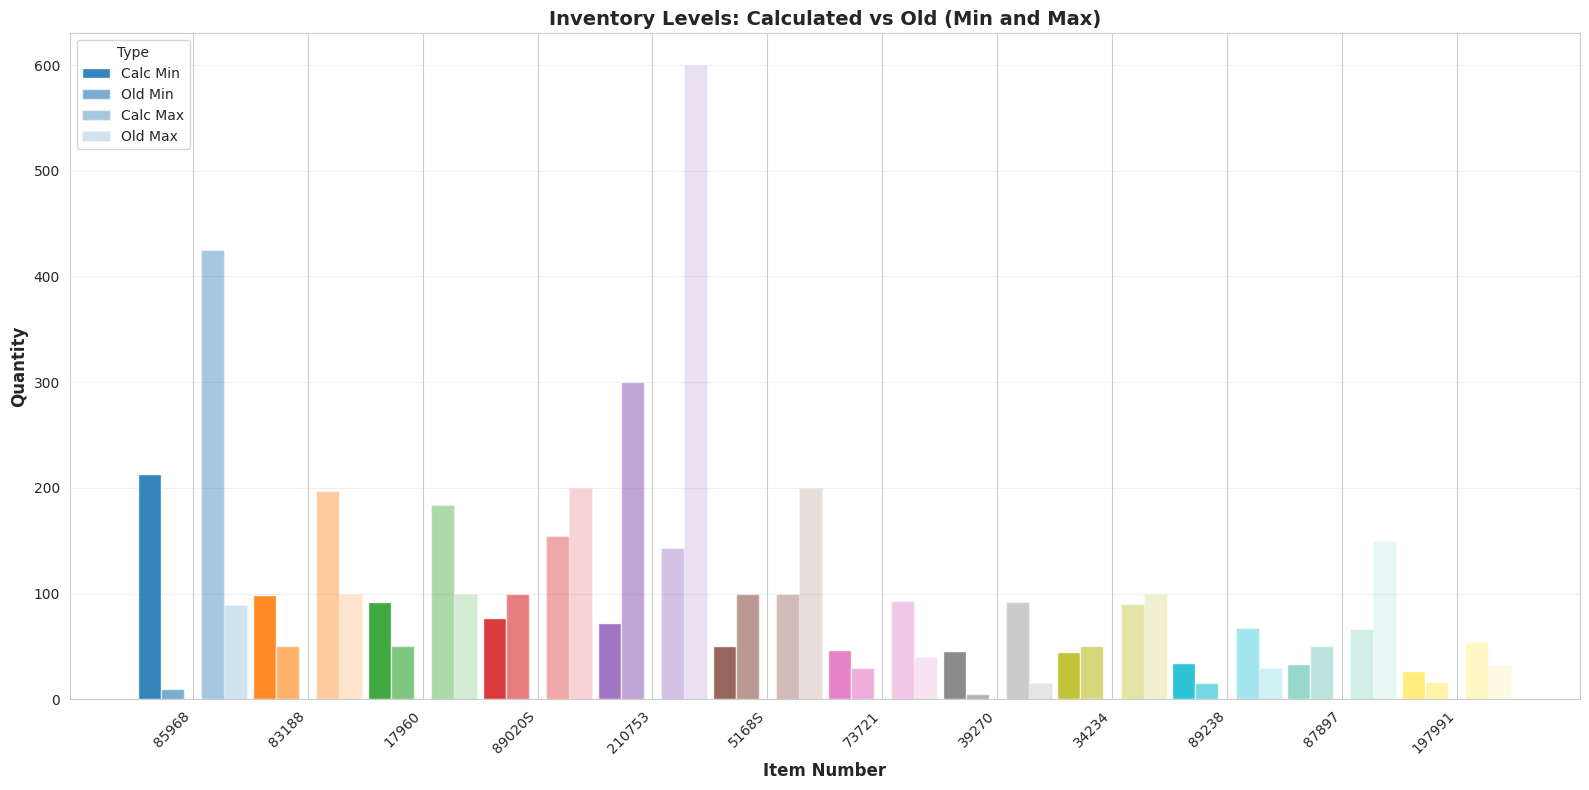

In [19]:
# Create figure for combined calc vs old (min and max)
fig, ax = plt.subplots(figsize=(16, 8))

# Set up bar positions for 4 bars per item with gap between mins and maxs
bar_width = 0.2
gap = 0.15  # Gap between min and max groups
x = np.arange(n_items)

# Plot bars for each item with different saturations
for i in range(n_items):
    color = base_colors[i]
    
    # Four bars per item with gap: calc_min, old_min [GAP] calc_max, old_max
    ax.bar(x[i] - 1.5*bar_width - gap/2, calc_min[i], bar_width, 
           color=color, alpha=0.9, label='Calc Min' if i == 0 else '')
    ax.bar(x[i] - 0.5*bar_width - gap/2, old_min[i], bar_width, 
           color=color, alpha=0.6, label='Old Min' if i == 0 else '')
    ax.bar(x[i] + 0.5*bar_width + gap/2, calc_max[i], bar_width, 
           color=color, alpha=0.4, label='Calc Max' if i == 0 else '')
    ax.bar(x[i] + 1.5*bar_width + gap/2, old_max[i], bar_width, 
           color=color, alpha=0.2, label='Old Max' if i == 0 else '')

# Customize plot
ax.set_xlabel('Item Number', fontsize=12, fontweight='bold')
ax.set_ylabel('Quantity', fontsize=12, fontweight='bold')
ax.set_title('Inventory Levels: Calculated vs Old (Min and Max)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(items, rotation=45, ha='right')
ax.legend(title='Type', loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Daily Usage Z-Score Analysis

Visualize how many standard deviations each day's usage is from the average. Z-scores help identify unusual usage spikes or drops.

In [20]:
# Calculate z-scores for each item's daily usage
df_daily_top12_copy = df_daily_top12.copy()

# For each item, calculate z-score of daily usage
z_scores = []
for item in top_12_items:
    item_data = df_daily_top12_copy[df_daily_top12_copy['item_no'].astype(str) == item].copy()
    
    # Calculate mean and std dev for this item
    mean_usage = item_data['usage'].mean()
    std_usage = item_data['usage'].std()
    
    # Calculate z-score for each day
    if std_usage > 0:
        item_data['z_score'] = (item_data['usage'] - mean_usage) / std_usage
    else:
        item_data['z_score'] = 0
    
    z_scores.append(item_data)

df_z_scores = pd.concat(z_scores, ignore_index=True)

print("Z-score data prepared")
print(f"Shape: {df_z_scores.shape}")

Z-score data prepared
Shape: (264, 11)


### Top 6 Highest Usage Items - Z-Score Trends

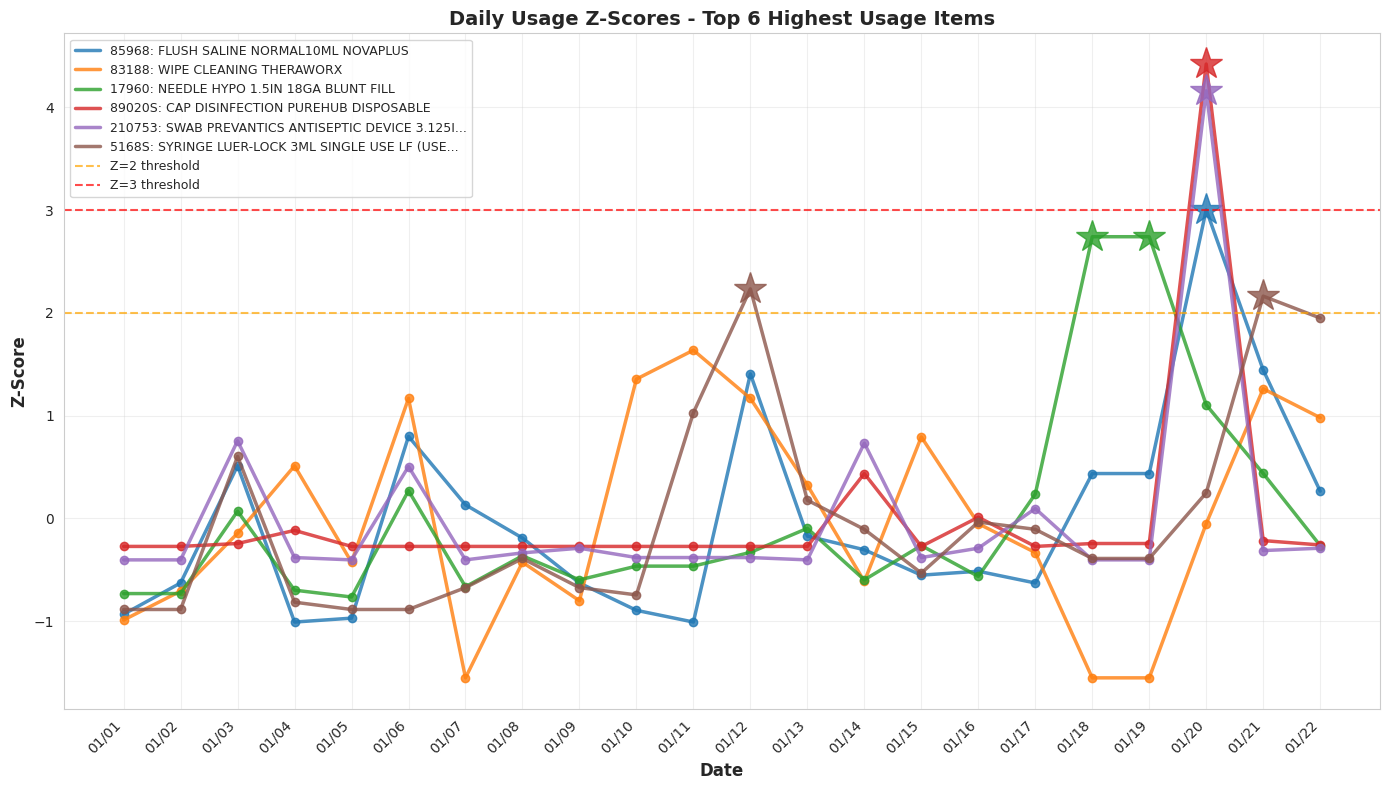

In [24]:
# Create z-score line chart for top 6 items
fig, ax = plt.subplots(figsize=(14, 8))

# Filter data for top 6
df_top6_z = df_z_scores[df_z_scores['item_no'].astype(str).isin(top_6_items)]

# Plot a line for each item
for i, item in enumerate(top_6_items):
    item_data = df_top6_z[df_top6_z['item_no'].astype(str) == item].sort_values('date')
    
    # Get the color for this item (match from bar charts)
    item_idx = items.index(item)
    color = base_colors[item_idx]
    
    # Get item description (limited to 40 characters)
    item_desc = df[df['item_no'].astype(str) == item]['item_desc'].values[0]
    item_desc_short = item_desc[:40] + '...' if len(item_desc) > 40 else item_desc
    
    # Separate points above and below z=2
    above_2 = item_data[item_data['z_score'] > 2]
    below_2 = item_data[item_data['z_score'] <= 2]
    
    # Plot line connecting all points
    ax.plot(item_data['date'], item_data['z_score'], 
            linewidth=2.5, color=color, alpha=0.8, label=f'{item}: {item_desc_short}')
    
    # Plot regular markers for points <= 2
    ax.plot(below_2['date'], below_2['z_score'], 
            marker='o', linestyle='', markersize=6, color=color, alpha=0.8)
    
    # Plot star markers for points > 2 (3x larger)
    if len(above_2) > 0:
        ax.plot(above_2['date'], above_2['z_score'], 
                marker='*', linestyle='', markersize=24, color=color, alpha=0.8)

# Add reference lines
ax.axhline(y=2, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Z=2 threshold')
ax.axhline(y=3, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Z=3 threshold')

# Customize plot
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Z-Score', fontsize=12, fontweight='bold')
ax.set_title('Daily Usage Z-Scores - Top 6 Highest Usage Items', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Bottom 6 (of Top 12) Items - Z-Score Trends

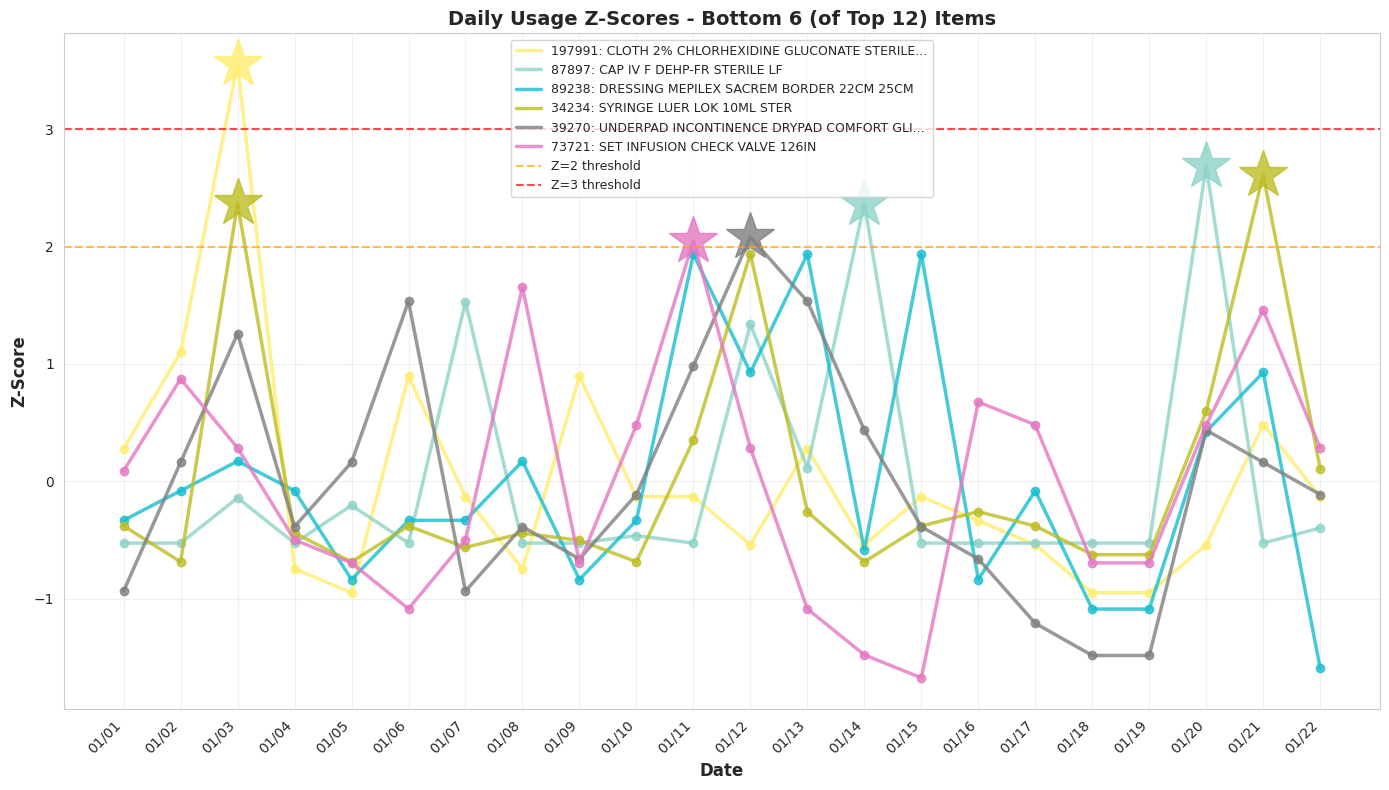

In [ ]:
# Create z-score line chart for bottom 6 items
fig, ax = plt.subplots(figsize=(14, 8))

# Filter data for bottom 6
df_bottom6_z = df_z_scores[df_z_scores['item_no'].astype(str).isin(bottom_6_items)]

# Plot a line for each item
for i, item in enumerate(bottom_6_items):
    item_data = df_bottom6_z[df_bottom6_z['item_no'].astype(str) == item].sort_values('date')
    
    # Get the color for this item (match from bar charts)
    item_idx = items.index(item)
    color = base_colors[item_idx]
    
    # Get item description (limited to 40 characters)
    item_desc = df[df['item_no'].astype(str) == item]['item_desc'].values[0]
    item_desc_short = item_desc[:40] + '...' if len(item_desc) > 40 else item_desc
    
    # Separate points above and below z=2
    above_2 = item_data[item_data['z_score'] > 2]
    below_2 = item_data[item_data['z_score'] <= 2]
    
    # Plot line connecting all points
    ax.plot(item_data['date'], item_data['z_score'], 
            linewidth=2.5, color=color, alpha=0.8, label=f'{item}: {item_desc_short}')
    
    # Plot regular markers for points <= 2
    ax.plot(below_2['date'], below_2['z_score'], 
            marker='o', linestyle='', markersize=6, color=color, alpha=0.8)
    
    # Plot star markers for points > 2 (3x larger)
    if len(above_2) > 0:
        ax.plot(above_2['date'], above_2['z_score'], 
                marker='*', linestyle='', markersize=24, color=color, alpha=0.8)

# Add reference lines
ax.axhline(y=2, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Z=2 threshold')
ax.axhline(y=3, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Z=3 threshold')

# Customize plot
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Z-Score', fontsize=12, fontweight='bold')
ax.set_title('Daily Usage Z-Scores - Bottom 6 (of Top 12) Items', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()